In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [8]:
# 1. 데이터 생성 및 CSV 저장
np.random.seed(42)
n_samples = 100
correlation_values = np.round(np.arange(-1.0, 1.1, 0.1), 1)

all_data = {}
for r in correlation_values:
    x = np.random.normal(0, 1, n_samples)
    err = np.random.normal(0, 1, n_samples)
    # 특정 상관계수 r을 갖도록 Y 생성
    y = r * x + np.sqrt(1 - r**2) * err
    all_data[f'r_{r}_X'] = x
    all_data[f'r_{r}_Y'] = y

df = pd.DataFrame(all_data)
df.to_csv('correlation_study_data.csv', index=False)
print("시스템: 'correlation_study_data.csv' 저장이 완료되었습니다.\n")

시스템: 'correlation_study_data.csv' 저장이 완료되었습니다.



In [9]:
# 2. 데이터 나열 및 상관계수 계산 결과 출력
# (텍스트 출력이 너무 길어질 수 있으므로, 각 그룹별 상위 5개 데이터만 예시로 나열합니다)
print("="*30)
print("데이터 리스트 및 상관계수 계산 결과")
print("="*30)

for r in correlation_values:
    x_val = df[f'r_{r}_X']
    y_val = df[f'r_{r}_Y']
    actual_r, _ = pearsonr(x_val, y_val)
    
    print(f"\n[대상 상관계수: {r}]")
    print("데이터 나열 (X, Y) 상위 5쌍:")
    for i in range(5):
        print(f"  ({x_val[i]:.4f}, {y_val[i]:.4f})", end="")
    print("\n  ... (중략) ...")
    print(f"결과: 계산된 Pearson 상관계수 = {actual_r:.4f}")
    print("-" * 20)

데이터 리스트 및 상관계수 계산 결과

[대상 상관계수: -1.0]
데이터 나열 (X, Y) 상위 5쌍:
  (0.4967, -0.4967)  (-0.1383, 0.1383)  (0.6477, -0.6477)  (1.5230, -1.5230)  (-0.2342, 0.2342)
  ... (중략) ...
결과: 계산된 Pearson 상관계수 = -1.0000
--------------------

[대상 상관계수: -0.9]
데이터 나열 (X, Y) 상위 5쌍:
  (0.3578, -0.6834)  (0.5608, -0.7489)  (1.0831, -0.6490)  (1.0538, -0.6824)  (-1.3777, 1.2308)
  ... (중략) ...
결과: 계산된 Pearson 상관계수 = -0.9301
--------------------

[대상 상관계수: -0.8]
데이터 나열 (X, Y) 상위 5쌍:
  (-1.5944, 1.8312)  (-0.5994, 1.6252)  (0.0052, -0.8433)  (0.0470, 0.3002)  (-0.4501, -0.0303)
  ... (중략) ...
결과: 계산된 Pearson 상관계수 = -0.8526
--------------------

[대상 상관계수: -0.7]
데이터 나열 (X, Y) 상위 5쌍:
  (0.7570, -0.9032)  (-0.9222, 1.3947)  (0.8696, -1.1117)  (1.3556, -1.9548)  (0.4134, -1.4011)
  ... (중략) ...
결과: 계산된 Pearson 상관계수 = -0.7648
--------------------

[대상 상관계수: -0.6]
데이터 나열 (X, Y) 상위 5쌍:
  (0.9383, -0.2680)  (-0.5160, -0.0050)  (0.0961, -0.0347)  (-0.4623, 1.3001)  (-0.4345, 0.4136)
  ... (중략) ...
결과: 계산된 Pearson 상관계수 = -0

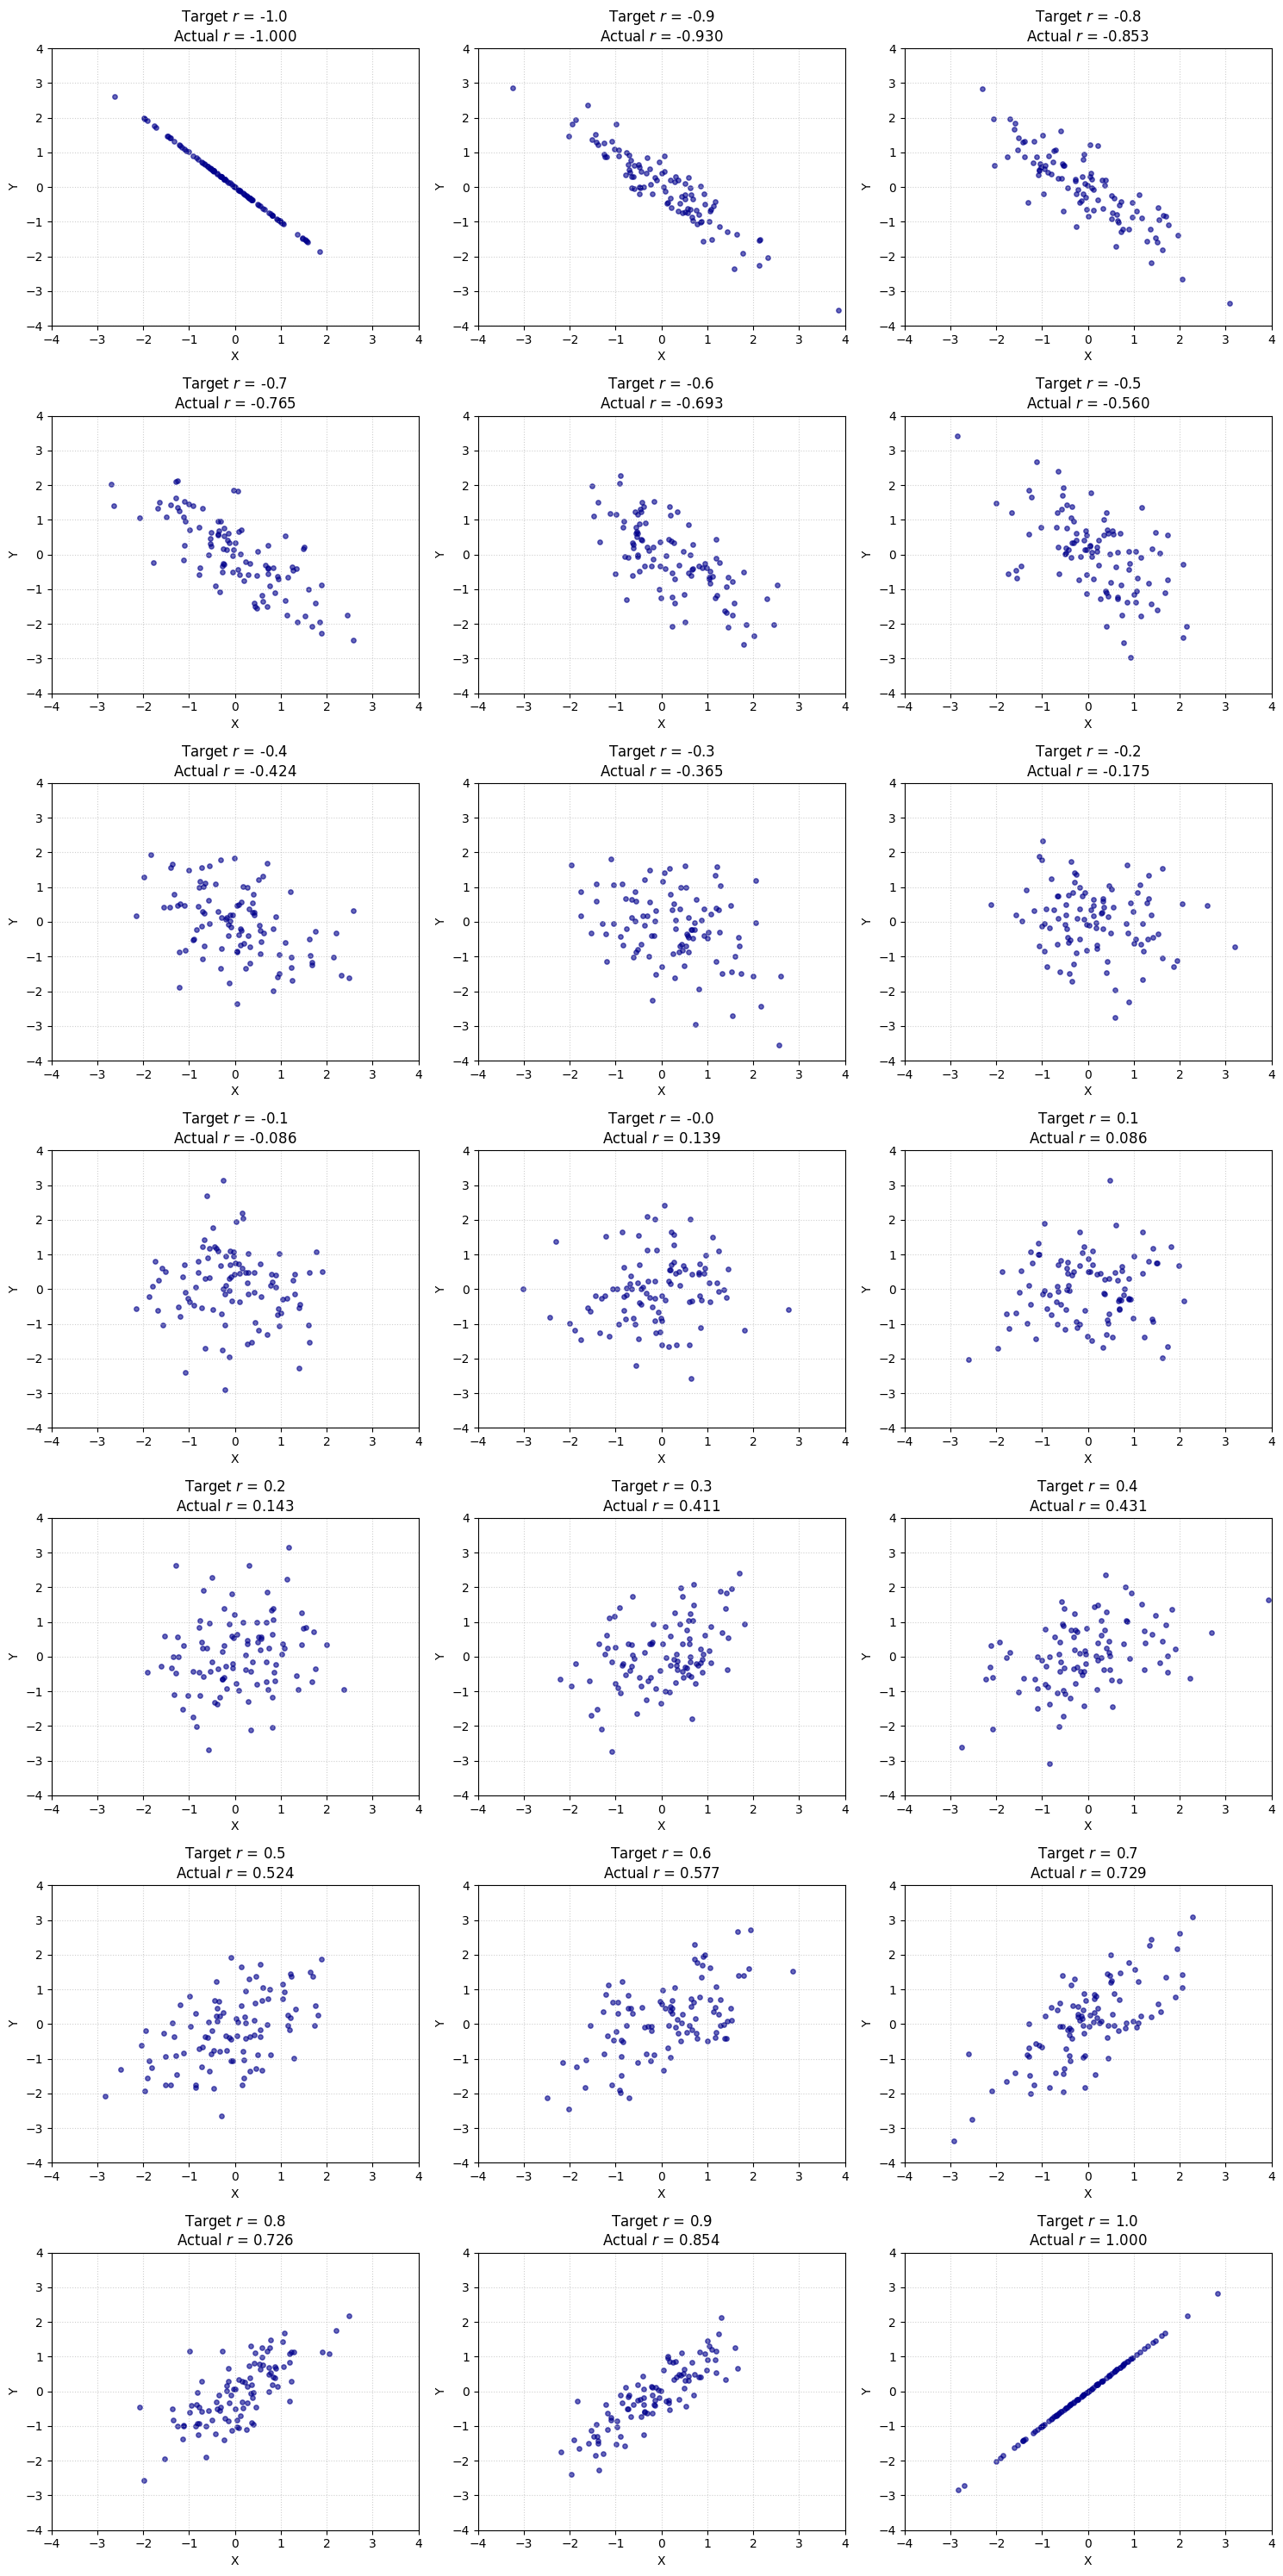

In [10]:
# 3. 모든 Scatterplot을 하나의 이미지에 출력
# 21개의 그래프를 7행 3열 구조로 배치
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 30))
axes = axes.flatten()

for i, r in enumerate(correlation_values):
    x_val = df[f'r_{r}_X']
    y_val = df[f'r_{r}_Y']
    actual_r, _ = pearsonr(x_val, y_val)
    
    axes[i].scatter(x_val, y_val, alpha=0.6, s=15, color='darkblue')
    axes[i].set_title(f'Target $r$ = {r}\nActual $r$ = {actual_r:.3f}', fontsize=12)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # x, y축 범위를 통일하여 시각적 비교의 객관성 확보
    axes[i].set_xlim(-4, 4)
    axes[i].set_ylim(-4, 4)

plt.tight_layout()
plt.show()